# Análise de Performance — Mindsight atividade 1

Os dados cobrem 4.281 funcionários avaliados ao longo de quatro semestres (2017–2019). A análise passa por cobertura, distribuição de scores, evolução temporal, médias por área, correlação com potencial, matriz 9-Box, fit cultural, atributos comportamentais, clusterização e regressão múltipla.

In [2]:
import pandas as pd
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

FILE = 'Dados - Atividade 1_limpo.xlsx'   # gerado por limpeza_dados.py
df = pd.read_excel(FILE)

## 1. Cobertura dos Dados por Semestre

Antes de entrar nos números de performance, vale checar quantos funcionários foram avaliados em cada período. A base tem 4.281 registros, mas a cobertura varia bastante — comparar médias entre semestres com volumes muito diferentes pode levar a conclusões erradas.

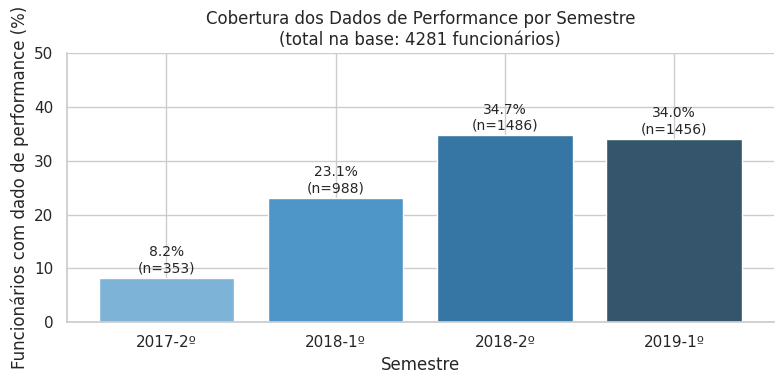

  label    n       pct
2017-2º  353  8.245737
2018-1º  988 23.078720
2018-2º 1486 34.711516
2019-1º 1456 34.010745


In [111]:
cols_perf = [c for c in df.columns if c.startswith("perf_")]

def extrair_tempo(c):
    parts = c.split("_")
    return int(parts[2]), int(parts[1])

ordem_cronologica = sorted(cols_perf, key=extrair_tempo)
labels_dict = {sem: f"{sem.split('_')[2]}-{sem.split('_')[1]}º" for sem in ordem_cronologica}

total = len(df)
cobertura = pd.DataFrame({
    "semestre": ordem_cronologica,
    "label": [labels_dict[s] for s in ordem_cronologica],
    "n":      [df[s].notna().sum() for s in ordem_cronologica],
    "pct":    [df[s].notna().mean() * 100 for s in ordem_cronologica],
})

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(cobertura["label"], cobertura["pct"], color=sns.color_palette("Blues_d", len(cobertura)))

for bar, (_, row) in zip(bars, cobertura.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{row['pct']:.1f}%\n(n={int(row['n'])})",
        ha="center", va="bottom", fontsize=10
    )

ax.set_ylim(0, 50)
ax.set_ylabel("Funcionários com dado de performance (%)")
ax.set_xlabel("Semestre")
ax.set_title(f"Cobertura dos Dados de Performance por Semestre\n(total na base: {total} funcionários)")
sns.despine()
plt.tight_layout()
plt.show()

print(cobertura[["label", "n", "pct"]].to_string(index=False))

A cobertura cresce ao longo do tempo: de 8% em 2017-2º para ~34% em 2018-2º e 2019-1º. O ponto fora da curva é 2017-2º — com apenas 353 funcionários avaliados, as médias daquele período (mais baixas do que o restante) não refletem necessariamente uma queda real de performance. Provavelmente é um grupo específico que já tinha dado de performance naquele momento. Dá pra usar comparações temporais, mas esse ponto merece atenção.

## 2. Distribuição de Scores de Performance

A escala vai de 1 a 3: 1 = Abaixo, 2 = Atende, 3 = Acima das expectativas. O gráfico mostra quantos funcionários caíram em cada nível por semestre.

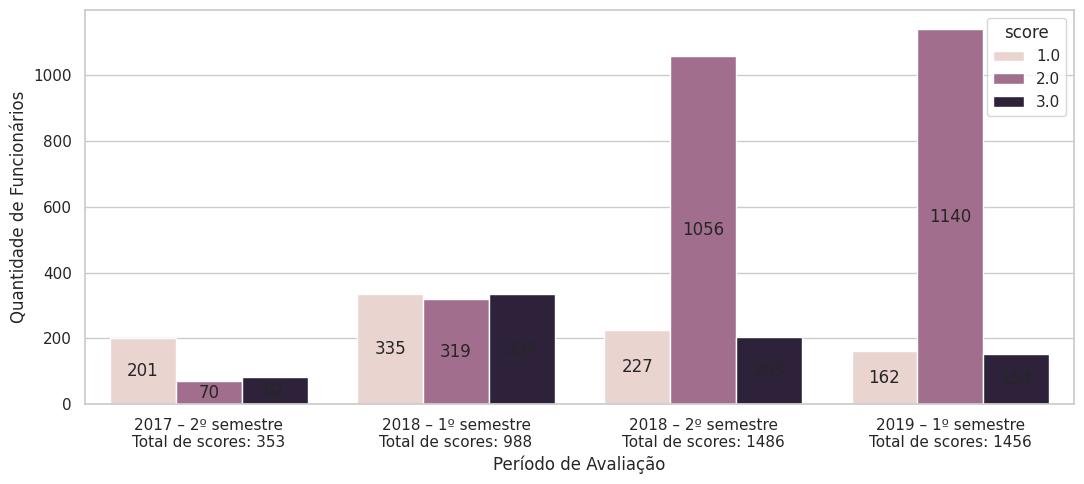

In [121]:
relacao = []

cols_perf = [c for c in df.columns if c.startswith("perf_")]
for col in cols_perf:
    vc = df[col].value_counts().sort_index()
    for score, contagem in vc.items():
        relacao.append({
            "semestre": col,
            "score": score,
            "qnt_func": contagem
        })

relacao = pd.DataFrame(relacao)

ordem_invertida = relacao["semestre"].drop_duplicates().tolist()[::-1]

# total por semestre (só para visualização)
totais = relacao.groupby("semestre")["qnt_func"].sum()

fig, ax = plt.subplots(figsize=(11, 5))

sns.barplot(
    data=relacao,
    x="semestre",
    y="qnt_func",
    hue="score",
    order=ordem_invertida,
    ax=ax
)

# valores dentro de cada barra
for container in ax.containers:
    ax.bar_label(container, label_type="center", fmt="%.0f")

# 🔹 criar rótulos legíveis + total
novos_labels = []
for sem in ordem_invertida:
    _, semestre, ano = sem.split("_")
    total = totais[sem]
    novos_labels.append(f"{ano} – {semestre}º semestre\nTotal de scores: {int(total)}")

ax.set_xticklabels(novos_labels, rotation=0)

ax.set_ylabel("Quantidade de Funcionários")
ax.set_xlabel("Período de Avaliação")

plt.tight_layout()
plt.show()

O score 2 domina em todos os semestres — entre 55% e 70% dos avaliados. Os scores 1 e 3 ficam em faixas parecidas (~15–25% cada), sem tendência clara de melhora ou piora ao longo do tempo. A concentração excessiva no score 2 é um sinal de alerta: quando a maioria cai sempre no meio, a avaliação perde poder discriminatório.

## 3. Evolução Temporal

Como a quantidade de funcionários avaliados e a distribuição dos scores evoluíram ao longo dos semestres — no total e por área.

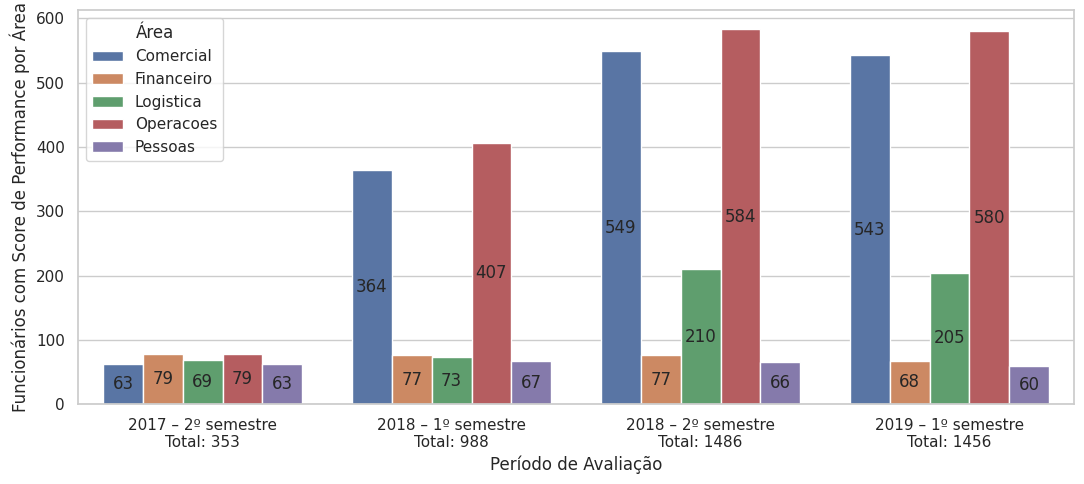

In [122]:
# supondo que seu df já esteja carregado
cols_perf = [c for c in df.columns if c.startswith("perf_")]

# criar dataframe de relação com área
relacao_area = []

for col in cols_perf:
    for area, grupo in df.groupby("Área"):
        # contar quantos registros têm valor preenchido
        qnt_com_valor = grupo[col].notna().sum()
        relacao_area.append({
            "semestre": col,
            "Área": area,
            "qnt_func": qnt_com_valor
        })

relacao_area = pd.DataFrame(relacao_area)

# inverter ordem dos semestres para visualização
ordem_invertida = relacao_area["semestre"].drop_duplicates().tolist()[::-1]

# gráfico de barras empilhadas por Área
fig, ax = plt.subplots(figsize=(11, 5))

sns.barplot(
    data=relacao_area,
    x="semestre",
    y="qnt_func",
    hue="Área",
    order=ordem_invertida,
    ax=ax
)

# valores dentro das barras
for container in ax.containers:
    ax.bar_label(container, label_type="center", fmt="%.0f")

# criar rótulos legíveis
totais = relacao_area.groupby("semestre")["qnt_func"].sum()
novos_labels = []
for sem in ordem_invertida:
    _, semestre, ano = sem.split("_")
    total = totais[sem]
    novos_labels.append(f"{ano} – {semestre}º semestre\nTotal: {int(total)}")

ax.set_xticklabels(novos_labels, rotation=0)
ax.set_ylabel("Funcionários com Score de Performance por Área")
ax.set_xlabel("Período de Avaliação")
plt.tight_layout()
plt.show()

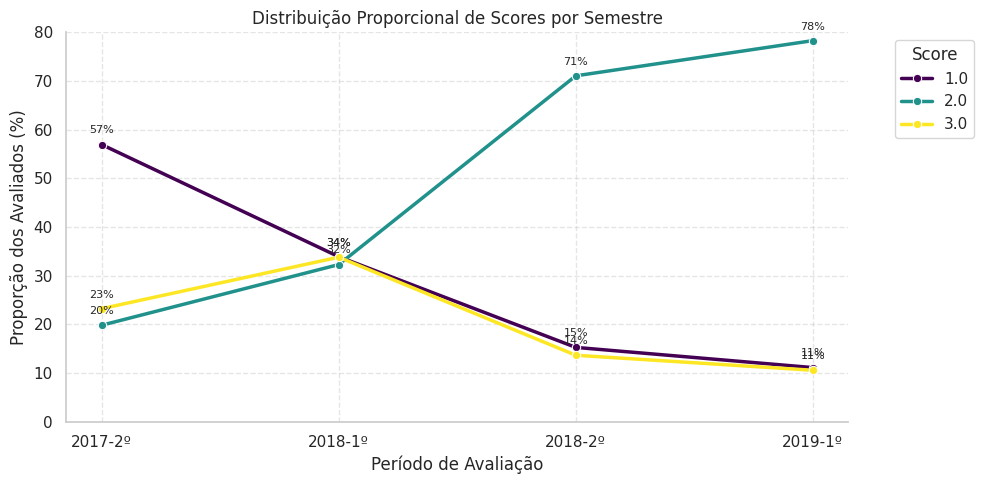

In [126]:
# Proporção de cada score por semestre (normalizado pela cobertura)
ordem_cronologica_rel = sorted(
    relacao["semestre"].unique(),
    key=lambda c: (int(c.split("_")[2]), int(c.split("_")[1]))
)

totais = relacao.groupby("semestre")["qnt_func"].sum()
relacao["pct"] = relacao.apply(lambda r: r["qnt_func"] / totais[r["semestre"]] * 100, axis=1)

relacao["semestre"] = pd.Categorical(relacao["semestre"], categories=ordem_cronologica_rel, ordered=True)

labels_dict = {s: f"{s.split('_')[2]}-{s.split('_')[1]}º" for s in ordem_cronologica_rel}
relacao["label"] = relacao["semestre"].map(labels_dict)
relacao["label"] = pd.Categorical(
    relacao["label"],
    categories=[labels_dict[s] for s in ordem_cronologica_rel],
    ordered=True
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=relacao,
    x="label",
    y="pct",
    hue="score",
    marker="o",
    linewidth=2.5,
    palette="viridis",
    ax=ax
)

# Anotar % em cada ponto
for score, grupo in relacao.groupby("score"):
    for _, row in grupo.iterrows():
        x_pos = [labels_dict[s] for s in ordem_cronologica_rel].index(row["label"])
        ax.annotate(
            f"{row['pct']:.0f}%",
            xy=(x_pos, row["pct"]),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

ax.set_ylabel("Proporção dos Avaliados (%)")
ax.set_xlabel("Período de Avaliação")
ax.set_title("Distribuição Proporcional de Scores por Semestre")
ax.set_ylim(0, 80)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title="Score", bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

Todas as áreas crescem em cobertura ao longo do tempo — não há exceção. Operações e Comercial concentram a maior parte dos avaliados, então suas médias são mais estáveis. Financeiro e Pessoas têm amostras bem menores (~27–29 funcionários com Potencial Bruto), o que torna comparações entre áreas menos confiáveis.

## 4. Médias de Performance por Área

A média do score (escala contínua de 1 a 3) de cada área ao longo dos semestres. Dois gráficos: um com a escala completa para referência, outro ampliado no range real para evidenciar diferenças pequenas.

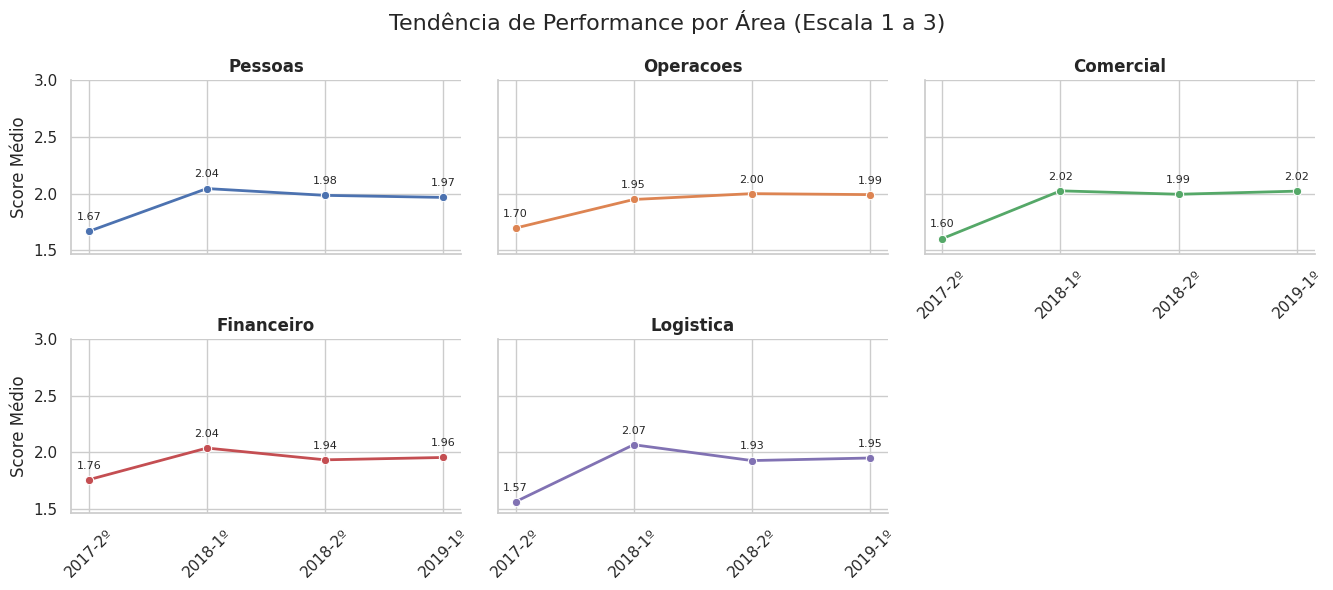

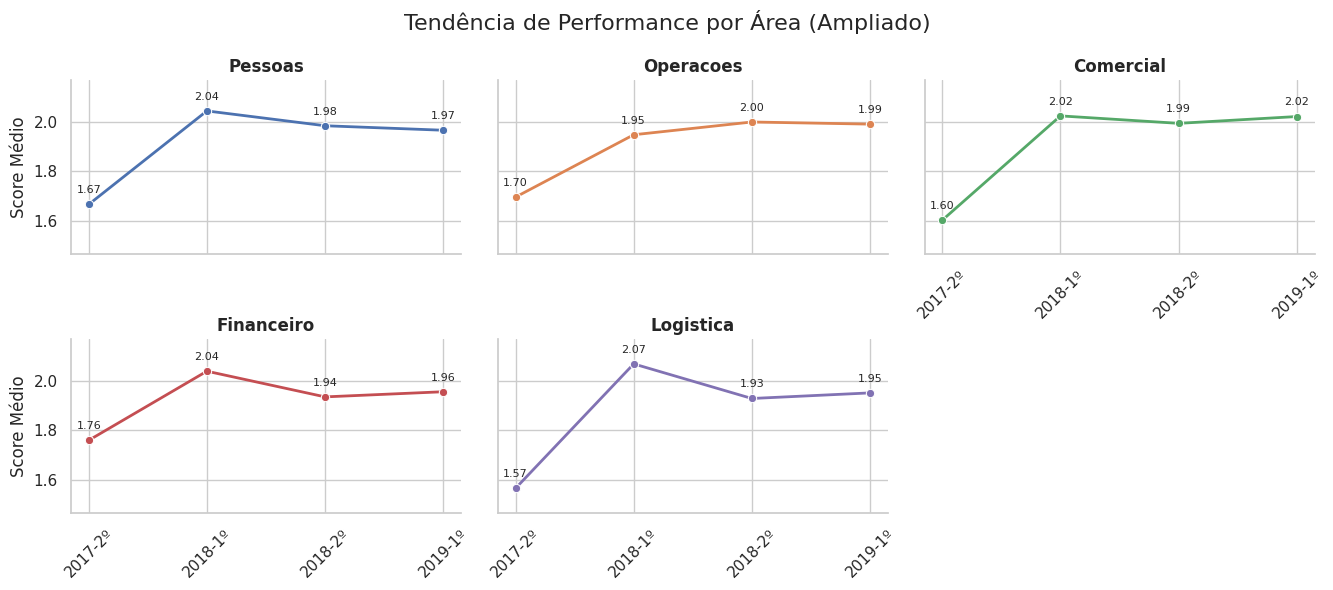

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Selecionar e ordenar cronologicamente as colunas de performance
cols_perf = [c for c in df.columns if c.startswith("perf_")]

def extrair_tempo(c):
    parts = c.split("_")
    return int(parts[2]), int(parts[1])  # (ano, semestre)

ordem_cronologica = sorted(cols_perf, key=extrair_tempo)

# 2. Formato longo
df_longo = df.melt(
    id_vars=["Área"],
    value_vars=cols_perf,
    var_name="semestre",
    value_name="score"
)
df_longo["score"] = pd.to_numeric(df_longo["score"], errors="coerce")

# 3. Média por semestre e área
relacao_media = (
    df_longo
    .groupby(["semestre", "Área"])["score"]
    .mean()
    .reset_index()
)

# 4. Garantir ordem cronológica e labels amigáveis
relacao_media["semestre"] = pd.Categorical(
    relacao_media["semestre"],
    categories=ordem_cronologica,
    ordered=True
)
relacao_media = relacao_media.sort_values("semestre")

labels_dict = {sem: f"{sem.split('_')[2]}-{sem.split('_')[1]}º" for sem in ordem_cronologica}
labels_crono = [labels_dict[sem] for sem in ordem_cronologica]

relacao_media["label_semestre"] = pd.Categorical(
    relacao_media["semestre"].map(labels_dict),
    categories=labels_crono,
    ordered=True
)

def plot_facetgrid(ylim, titulo):
    sns.set_theme(style="whitegrid")
    g = sns.FacetGrid(
        relacao_media,
        col="Área",
        col_wrap=3,
        height=3,
        aspect=1.5,
        hue="Área"
    )
    g.map(sns.lineplot, "label_semestre", "score", marker="o", linewidth=2)
    g.set_axis_labels("", "Score Médio")
    g.set_titles("{col_name}", fontweight="bold")
    g.set(ylim=ylim)

    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=45)

    areas = relacao_media["Área"].unique()
    for ax, area in zip(g.axes.flat, areas):
        dados_area = relacao_media[relacao_media["Área"] == area]
        for _, row in dados_area.iterrows():
            x_pos = labels_crono.index(row["label_semestre"])
            ax.annotate(
                f"{row['score']:.2f}",
                xy=(x_pos, row["score"]),
                xytext=(0, 8),
                textcoords="offset points",
                ha="center",
                fontsize=8
            )

    g.fig.suptitle(titulo, fontsize=16)
    plt.tight_layout()
    plt.show()

margem = 0.1
y_min = relacao_media["score"].min() - margem
y_max_amp = relacao_media["score"].max() + margem

plot_facetgrid(ylim=(y_min, 3),       titulo="Tendência de Performance por Área (Escala 1 a 3)")
plot_facetgrid(ylim=(y_min, y_max_amp), titulo="Tendência de Performance por Área (Ampliado)")

Nos semestres de maior cobertura (2018-1º em diante), todas as áreas ficam entre 1.9 e 2.1 — desempenho praticamente homogêneo. Não tem área que se destaque consistentemente, nem pra cima nem pra baixo. A queda generalizada em 2017-2º é provavelmente artefato de seleção (só 8% da base), não uma piora real.

## 5. Correlação: Potencial Bruto x Performance

928 funcionários (~22% da base) têm avaliação de Potencial Bruto. Quem tem potencial mais alto entrega mais? Calculamos a média de performance de cada funcionário nos semestres em que foi avaliado e cruzamos com o Potencial Bruto.

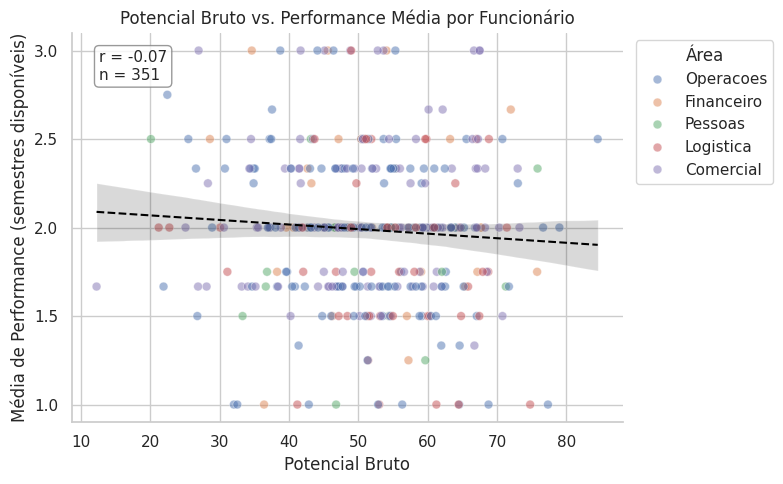

In [125]:
cols_perf = [c for c in df.columns if c.startswith("perf_")]

perf_media = df[cols_perf].mean(axis=1)
validos = pd.DataFrame({
    "Potencial Bruto": df["Potencial Bruto"],
    "perf_media": perf_media,
    "Área": df["Área"]
}).dropna()

correlacao = validos["Potencial Bruto"].corr(validos["perf_media"])

fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=validos,
    x="Potencial Bruto",
    y="perf_media",
    hue="Área",
    alpha=0.5,
    s=40,
    ax=ax
)
sns.regplot(
    data=validos,
    x="Potencial Bruto",
    y="perf_media",
    scatter=False,
    color="black",
    line_kws={"linewidth": 1.5, "linestyle": "--"},
    ax=ax
)

ax.annotate(
    f"r = {correlacao:.2f}\nn = {len(validos)}",
    xy=(0.05, 0.88),
    xycoords="axes fraction",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
)

ax.set_xlabel("Potencial Bruto")
ax.set_ylabel("Média de Performance (semestres disponíveis)")
ax.set_title("Potencial Bruto vs. Performance Média por Funcionário")
ax.set_yticks([1, 1.5, 2, 2.5, 3])
ax.legend(title="Área", bbox_to_anchor=(1.01, 1), loc="upper left")
sns.despine()
plt.tight_layout()
plt.show()

A correlação de Pearson é **r ≈ −0.07** — praticamente zero. O Potencial Bruto não prediz performance nos semestres analisados.

Isso levanta duas questões imediatas: o instrumento está medindo o construto certo? Ou o período analisado é curto demais para a relação aparecer? Seja qual for a resposta, usar Potencial Bruto como critério principal de seleção ou promoção é problemático com esse dado na mão. Vale investigar por área e com um horizonte maior antes de qualquer decisão.

## 6. Matriz 9-Box: Potencial x Performance

A **Matriz 9-Box** é uma ferramenta clássica de People Analytics que avalia cada funcionário em duas dimensões:

- **Performance** — o que a pessoa entrega hoje (Baixa / Média / Alta)
- **Potencial** — até onde a pessoa pode chegar (Baixo / Médio / Alto)

Cruzando as duas, cada funcionário cai em um dos 9 quadrantes, cada um com uma interpretação e ação recomendada:

```
                   Performance
               Baixa      Média       Alta
            ┌──────────┬──────────┬──────────┐
Alto        │  Enigma  │  Alto    │  Estrela │
Potencial   │          │  Potenc. │          │
            ├──────────┼──────────┼──────────┤
Médio       │  Em      │  Core    │  Forte   │
Potencial   │  Desenv. │          │  Desemp. │
            ├──────────┼──────────┼──────────┤
Baixo       │  Em      │Eficiente │  Sólido  │
Potencial   │  Risco   │          │          │
            └──────────┴──────────┴──────────┘
```

| Quadrante | Perfil | Ação sugerida |
|---|---|---|
| **Estrela** | Entrega muito e tem futuro | Investir, reter, preparar para liderança |
| **Enigma** | Tem capacidade mas não entrega | Investigar causa — cargo errado? falta de suporte? |
| **Core** | Desempenho e potencial médios | Manter engajado, é a base saudável da empresa |
| **Sólido** | Entrega bem mas chegou no teto | Reconhecer sem prometer promoção |
| **Em Risco** | Baixa performance e baixo potencial | Plano de melhoria ou desligamento |

A ideia central é que **só olhar performance não basta**. Um funcionário que entrega bem hoje mas sem potencial de crescimento precisa de uma estratégia diferente de alguém que entrega pouco mas tem alto potencial — o segundo pode estar no cargo errado ou sem o suporte necessário.

---
**Configuração utilizada:**
- Performance dividida nos cortes naturais da escala (≤ 1.5 = Baixa, 1.5–2.5 = Média, > 2.5 = Alta)
- Potencial Bruto dividido em tercis da distribuição observada
- Base: funcionários com **ao menos 2 avaliações de performance** e **Potencial Bruto preenchido**

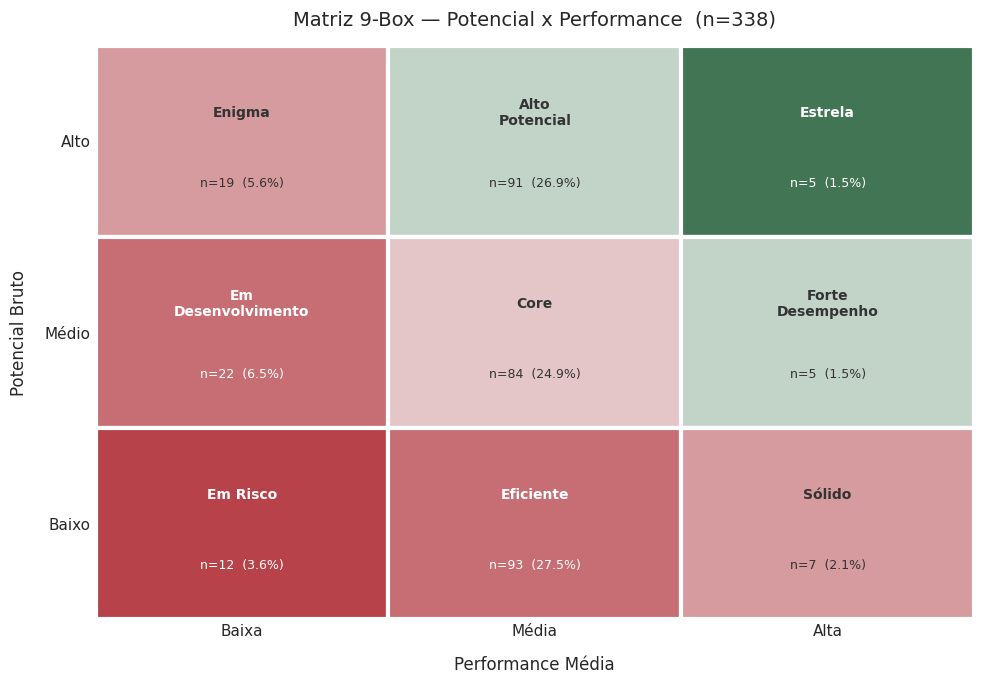

Cortes de Potencial Bruto:  Baixo ≤ 47.1  |  Médio 47.1–57.2  |  Alto > 57.2
Funcionários incluídos: 338  (filtro: ≥ 2 avaliações de performance + Potencial Bruto preenchido)


In [131]:
from matplotlib.colors import Normalize
import matplotlib.cm as cm

cols_perf = [c for c in df.columns if c.startswith("perf_")]

n_avaliacoes = df[cols_perf].notna().sum(axis=1)
perf_media   = df[cols_perf].mean(axis=1)

dados_9box = pd.DataFrame({
    "Potencial Bruto": df["Potencial Bruto"],
    "perf_media":      perf_media,
    "n_avaliacoes":    n_avaliacoes,
    "Área":            df["Área"]
})

# Filtro: ao menos 2 semestres avaliados E Potencial Bruto preenchido
dados_9box = dados_9box[
    (dados_9box["n_avaliacoes"] >= 2) &
    (dados_9box["Potencial Bruto"].notna())
]

dados_9box["perf_cat"] = pd.cut(
    dados_9box["perf_media"],
    bins=[0, 1.5, 2.5, 3.01],
    labels=["Baixa", "Média", "Alta"],
    include_lowest=True
)

q33 = dados_9box["Potencial Bruto"].quantile(0.33)
q66 = dados_9box["Potencial Bruto"].quantile(0.66)
dados_9box["pot_cat"] = pd.cut(
    dados_9box["Potencial Bruto"],
    bins=[0, q33, q66, 101],
    labels=["Baixo", "Médio", "Alto"],
    include_lowest=True
)

matriz_n = (
    dados_9box.groupby(["pot_cat", "perf_cat"], observed=True)
    .size()
    .unstack(fill_value=0)
    [["Baixa", "Média", "Alta"]]
    .loc[["Alto", "Médio", "Baixo"]]
)
total = matriz_n.values.sum()

quadrantes = {
    ("Alto",  "Alta"):  "Estrela",
    ("Alto",  "Média"): "Alto\nPotencial",
    ("Alto",  "Baixa"): "Enigma",
    ("Médio", "Alta"):  "Forte\nDesempenho",
    ("Médio", "Média"): "Core",
    ("Médio", "Baixa"): "Em\nDesenvolvimento",
    ("Baixo", "Alta"):  "Sólido",
    ("Baixo", "Média"): "Eficiente",
    ("Baixo", "Baixa"): "Em Risco",
}

rank   = {"Baixo": 1, "Médio": 2, "Alto": 3, "Baixa": 1, "Média": 2, "Alta": 3}
valores = {(p, f): rank[p] * rank[f] for p in ["Alto","Médio","Baixo"]
                                      for f in ["Alta","Média","Baixa"]}

cmap = sns.diverging_palette(10, 140, s=60, l=45, n=256, as_cmap=True)
norm = Normalize(vmin=1, vmax=9)

pots  = ["Alto", "Médio", "Baixo"]
perfs = ["Baixa", "Média", "Alta"]

fig, ax = plt.subplots(figsize=(10, 7))

for i, pot in enumerate(pots):
    for j, perf in enumerate(perfs):
        rgba = cmap(norm(valores[(pot, perf)]))
        luminancia = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
        fg = "white" if luminancia < 0.55 else "#333333"

        rect = plt.Rectangle([j, 2 - i], 1, 1, color=rgba, ec="white", lw=3)
        ax.add_patch(rect)

        n   = matriz_n.loc[pot, perf]
        pct = n / total * 100
        ax.text(j + 0.5, 2 - i + 0.65, quadrantes[(pot, perf)],
                ha="center", va="center", fontsize=10, fontweight="bold", color=fg)
        ax.text(j + 0.5, 2 - i + 0.28, f"n={n}  ({pct:.1f}%)",
                ha="center", va="center", fontsize=9, color=fg)

ax.set_xlim(0, 3)
ax.set_ylim(0, 3)
ax.set_xticks([0.5, 1.5, 2.5])
ax.set_xticklabels(["Baixa", "Média", "Alta"], fontsize=11)
ax.set_yticks([0.5, 1.5, 2.5])
ax.set_yticklabels(["Baixo", "Médio", "Alto"], fontsize=11)
ax.set_xlabel("Performance Média", fontsize=12, labelpad=12)
ax.set_ylabel("Potencial Bruto", fontsize=12, labelpad=12)
ax.set_title(f"Matriz 9-Box — Potencial x Performance  (n={total})", fontsize=14, pad=15)
ax.tick_params(length=0)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

print(f"Cortes de Potencial Bruto:  Baixo ≤ {q33:.1f}  |  Médio {q33:.1f}–{q66:.1f}  |  Alto > {q66:.1f}")
print(f"Funcionários incluídos: {total}  (filtro: ≥ 2 avaliações de performance + Potencial Bruto preenchido)")

**Como o cálculo foi feito:**

Para posicionar cada funcionário na matriz, precisamos de dois números: performance média e Potencial Bruto.

A performance média é a média dos scores de todos os semestres em que o funcionário foi avaliado. Alguém com scores 2, 3 e 2 em três semestres fica com média 2.33. Quem tem menos de 2 avaliações foi excluído — média de um único ponto não é representativa. O resultado foi dividido em três faixas pelos cortes naturais da escala: abaixo de 1.5 é Baixa, entre 1.5 e 2.5 é Média, acima de 2.5 é Alta.

O Potencial Bruto já vem como número contínuo (0–100). Para criar três faixas de tamanho similar, usamos tercis — o terço inferior vira Potencial Baixo (até ~47 pontos), o do meio Potencial Médio (~47–57) e o superior Potencial Alto (acima de ~57). Com os dois dados disponíveis, cada funcionário cai em um dos 9 quadrantes.

**Resultado:** se o Potencial Bruto fosse um bom preditor, esperaríamos ver o Alto Potencial concentrado na coluna da direita (Alta Performance) e o Baixo Potencial na esquerda. A matriz vai mostrar o contrário — a distribuição de performance é parecida nas três faixas de potencial, consistente com o r = −0.07 da seção anterior.

## 7. Listagem por Quadrante da Matriz 9-Box

Distribuição dos 338 funcionários incluídos na matriz (filtro: ≥ 2 avaliações de performance + Potencial Bruto preenchido):

| Quadrante | Potencial | Performance | n |
|---|---|---|---:|
| **Eficiente** | Baixo | Média | 93 |
| **Alto Potencial** | Alto | Média | 91 |
| **Core** | Médio | Média | 84 |
| **Em Desenvolvimento** | Médio | Baixa | 22 |
| **Enigma** | Alto | Baixa | 19 |
| **Em Risco** | Baixo | Baixa | 12 |
| **Sólido** | Baixo | Alta | 7 |
| **Estrela** | Alto | Alta | 5 |
| **Forte Desempenho** | Médio | Alta | 5 |

A seguir, a listagem completa de todos os funcionários com seu respectivo quadrante.

In [4]:
cols_perf = [c for c in df.columns if c.startswith("perf_")]

n_avaliacoes = df[cols_perf].notna().sum(axis=1)
perf_media   = df[cols_perf].mean(axis=1)

df_9box = pd.DataFrame({
    "Nome Completo":   df["Nome Completo"],
    "CPF":             df["CPF"],
    "Área":            df["Área"],
    "Potencial Bruto": df["Potencial Bruto"],
    "perf_media":      perf_media,
    "n_avaliacoes":    n_avaliacoes,
})

df_9box = df_9box[
    (df_9box["n_avaliacoes"] >= 2) &
    (df_9box["Potencial Bruto"].notna())
].copy()

df_9box["perf_cat"] = pd.cut(
    df_9box["perf_media"],
    bins=[0, 1.5, 2.5, 3.01],
    labels=["Baixa", "Média", "Alta"],
    include_lowest=True
)

q33 = df_9box["Potencial Bruto"].quantile(0.33)
q66 = df_9box["Potencial Bruto"].quantile(0.66)
df_9box["pot_cat"] = pd.cut(
    df_9box["Potencial Bruto"],
    bins=[0, q33, q66, 101],
    labels=["Baixo", "Médio", "Alto"],
    include_lowest=True
)

quadrantes_label = {
    ("Alto",  "Alta"):  "Estrela",
    ("Alto",  "Média"): "Alto Potencial",
    ("Alto",  "Baixa"): "Enigma",
    ("Médio", "Alta"):  "Forte Desempenho",
    ("Médio", "Média"): "Core",
    ("Médio", "Baixa"): "Em Desenvolvimento",
    ("Baixo", "Alta"):  "Sólido",
    ("Baixo", "Média"): "Eficiente",
    ("Baixo", "Baixa"): "Em Risco",
}

df_9box["quadrante"] = df_9box.apply(
    lambda r: quadrantes_label[(str(r["pot_cat"]), str(r["perf_cat"]))], axis=1
)

# ── visão geral por quadrante ──────────────────────────────────────────────
print("Funcionários por quadrante:")
print(df_9box["quadrante"].value_counts().to_string())
df_9box[["Nome Completo", "CPF", "Área", "Potencial Bruto", "perf_media", "quadrante"]].head(10)

Funcionários por quadrante:
quadrante
Eficiente             93
Alto Potencial        91
Core                  84
Em Desenvolvimento    22
Enigma                19
Em Risco              12
Sólido                 7
Estrela                5
Forte Desempenho       5


,Nome Completo,CPF,Área,Potencial Bruto,perf_media,quadrante
43,André Costa,678.042.935-18,Operacoes,53.65,2.50,Core
46,Mirella Viana,375.410.982-13,Operacoes,22.46,2.75,Sólido
50,Ian Da Cruz,584.619.230-14,Financeiro,63.25,2.50,Alto Potencial
51,Letícia Campos,432.950.186-42,Pessoas,20.09,2.50,Eficiente
52,João Felipe Moura,675.489.102-58,Logistica,42.06,1.75,Eficiente
54,Isis Barros,047.821.956-31,Financeiro,59.07,1.75,Alto Potencial
57,Cauê Gomes,209.731.654-99,Logistica,48.43,1.50,Em Desenvolvimento
59,Mariane Vieira,759.460.831-39,Logistica,67.03,2.50,Alto Potencial
60,Davi Lucca Vieira,238.490.617-87,Operacoes,50.72,1.75,Core
61,Diego Da Conceição,132.605.489-98,Operacoes,50.42,2.50,Core


In [8]:
from IPython.display import HTML

ordem_quadrantes = [
    "Estrela", "Forte Desempenho", "Alto Potencial",
    "Sólido", "Core", "Em Desenvolvimento",
    "Eficiente", "Enigma", "Em Risco",
]

df_9box["quadrante"] = pd.Categorical(df_9box["quadrante"], categories=ordem_quadrantes, ordered=True)

df_todos = (
    df_9box[["Nome Completo", "CPF", "Área", "Potencial Bruto", "perf_media", "quadrante"]]
    .sort_values(["quadrante", "perf_media"], ascending=[True, False])
    .reset_index(drop=True)
)

print(f"Total de funcionários listados: {len(df_todos)}")

HTML(f"""
<div style="height:400px; overflow-y:scroll; border:1px solid #ccc;">
{df_todos.to_html()}
</div>
""")

Total de funcionários listados: 338


,Nome Completo,CPF,Área,Potencial Bruto,perf_media,quadrante
0,Marcela Ramos,296.435.718-82,Comercial,66.69,3.000000,Estrela
1,Ian Da Luz,402.813.597-41,Comercial,67.52,3.000000,Estrela
2,Larissa Pereira,902.153.678-12,Financeiro,72.00,2.666667,Estrela
3,Ana Vitória Costa,109.674.283-78,Comercial,60.14,2.666667,Estrela
4,Sofia Teixeira,593.874.601-93,Comercial,62.17,2.666667,Estrela
5,Lucca Da Paz,739.145.086-39,Operacoes,55.35,3.000000,Forte Desempenho
6,Marcelo Da Cruz,715.390.846-39,Comercial,53.65,3.000000,Forte Desempenho
7,Yago Almeida,472.651.098-31,Comercial,48.85,3.000000,Forte Desempenho
8,Breno Da Mata,706.219.348-87,Comercial,52.81,3.000000,Forte Desempenho
9,Luiz Otávio Oliveira,193.807.425-41,Logistica,48.97,3.000000,Forte Desempenho


## 8. Fit Cultural por Área

O assessment de Cultura mede o quanto o perfil de valores e comportamento do funcionário se alinha à cultura da organização. A pontuação é contínua (0–100) e classificada em 7 faixas: Muito-Baixo, Baixo, Médio-Baixo, Médio, Médio-Alto, Alto, Muito-Alto.

Aqui vemos a distribuição proporcional das classificações por área e a dispersão de pontuação via boxplot.

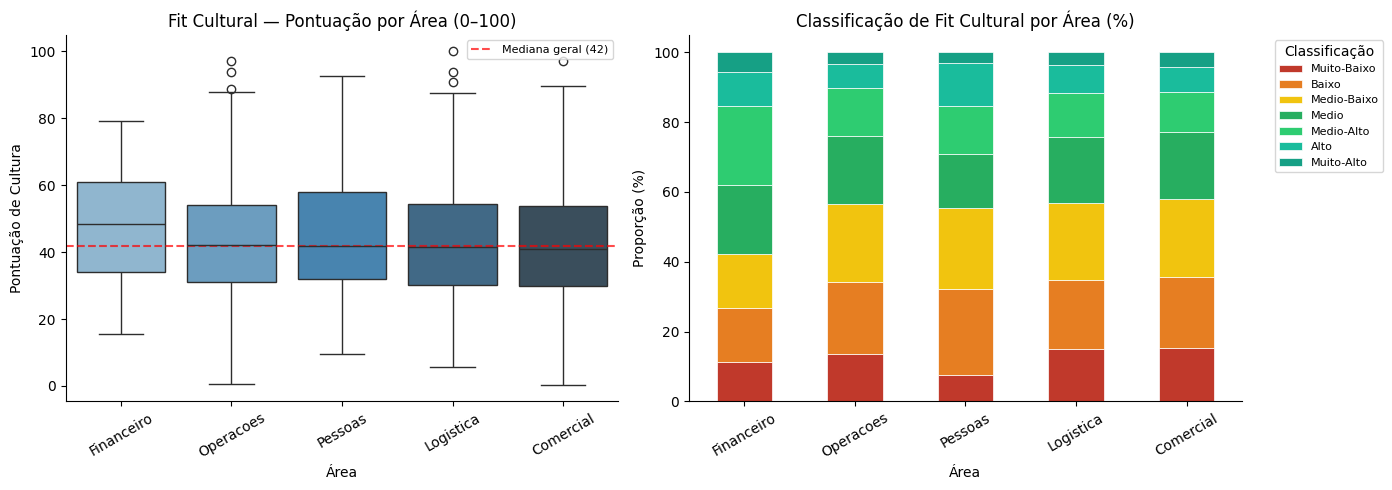


Mediana de Cultura por área:
Área
Financeiro    48.5
Operacoes     42.1
Pessoas       41.7
Logistica     41.5
Comercial     41.0


In [3]:
import numpy as np

cols_perf = [c for c in df.columns if c.startswith("perf_")]
cult_col  = "Cultura pontuação"
class_col = "Cultura classificação"

df_cult_area = df[["Área", cult_col, class_col]].dropna(subset=[cult_col])
areas_ord = (df_cult_area.groupby("Área")[cult_col]
             .median().sort_values(ascending=False).index.tolist())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot de pontuação por área
sns.boxplot(data=df_cult_area, x="Área", y=cult_col, order=areas_ord,
            palette="Blues_d", ax=ax1)
med_geral = df_cult_area[cult_col].median()
ax1.axhline(med_geral, color="red", linestyle="--", alpha=0.7,
            label=f"Mediana geral ({med_geral:.0f})")
ax1.set_title("Fit Cultural — Pontuação por Área (0–100)")
ax1.set_xlabel("Área")
ax1.set_ylabel("Pontuação de Cultura")
ax1.legend(fontsize=8)
ax1.tick_params(axis="x", rotation=30)
sns.despine(ax=ax1)

# Stacked bar: proporção de classificações por área
ordem_class = ["Muito-Baixo", "Baixo", "Medio-Baixo", "Medio",
               "Medio-Alto", "Alto", "Muito-Alto"]
df_cls = df[["Área", class_col]].dropna()
classes_pres = [c for c in ordem_class if c in df_cls[class_col].unique()]
props = (df_cls.groupby(["Área", class_col]).size()
         .unstack(fill_value=0)
         .reindex(columns=classes_pres, fill_value=0))
props_pct = (props.div(props.sum(axis=1), axis=0) * 100).reindex(areas_ord)

cores = ["#c0392b", "#e67e22", "#f1c40f", "#27ae60",
         "#2ecc71", "#1abc9c", "#16a085"]
props_pct.plot(kind="bar", stacked=True, ax=ax2,
               color=cores[:len(classes_pres)], edgecolor="white", linewidth=0.5)
ax2.set_title("Classificação de Fit Cultural por Área (%)")
ax2.set_xlabel("Área")
ax2.set_ylabel("Proporção (%)")
ax2.legend(title="Classificação", bbox_to_anchor=(1.05, 1),
           loc="upper left", fontsize=8)
ax2.tick_params(axis="x", rotation=30)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

print("\nMediana de Cultura por área:")
print(df_cult_area.groupby("Área")[cult_col].median()
      .sort_values(ascending=False).round(1).to_string())


A mediana geral de Cultura é ~42/100 — a maioria dos funcionários avaliados fica nas faixas Baixo e Médio-Baixo. O fit cultural geral da organização é baixo. As áreas com mediana maior tendem a ter mais funcionários nas faixas Médio-Alto e Alto, mas a dispersão é alta em todo lugar — há muita variação dentro de cada área. Financeiro e Pessoas têm amostras pequenas, então qualquer conclusão sobre elas é frágil. Um fit cultural sistematicamente baixo sugere desalinhamento entre o perfil contratado e os valores da empresa.

## 9. Perfil de Atributos por Quadrante da 9-Box

Os 16 atributos comportamentais (escala 0–100) cobrem quatro dimensões:
- **Cognitiva**: Capacidade analítica, Pensamento conceitual, Reflexão, Pensamento criativo, Planejamento e organização
- **Social**: Comunicação, Consideração pelos outros, Influência, Sociabilidade, Facilitação
- **Adaptativa**: Flexibilidade, Estabilidade emocional
- **Executiva**: Ambição, Iniciativa, Assertividade, Tomada de riscos

O radar compara o perfil médio entre quadrantes selecionados — o que diferencia comportamentalmente quem entrega de quem não entrega.

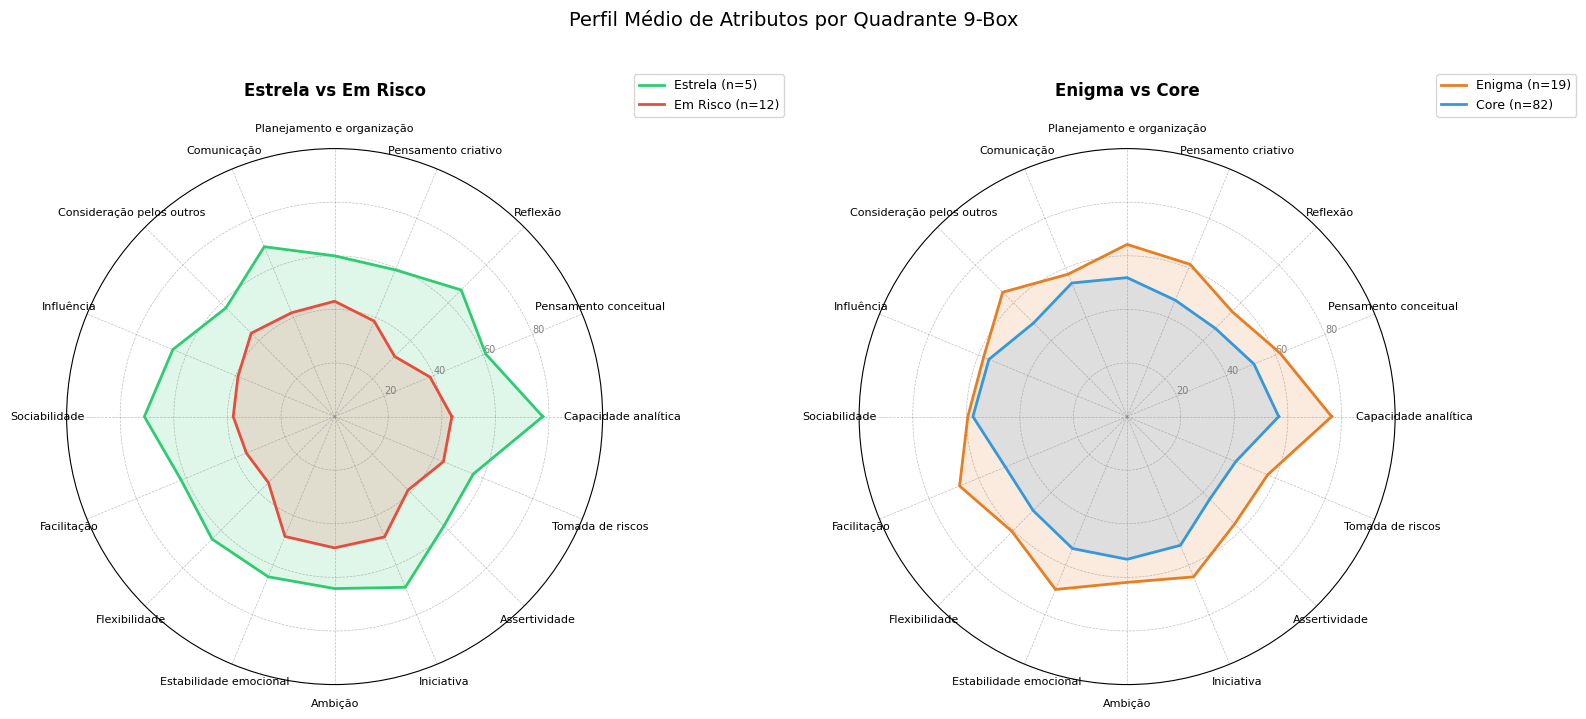


Média dos atributos por quadrante (quadrantes selecionados):

quadrante                   Estrela  Enigma  Core  Em Risco
Capacidade analítica           77.7    76.3  56.6      43.8
Pensamento conceitual          61.0    61.8  51.2      38.6
Reflexão                       66.8    55.4  46.6      31.7
Pensamento criativo            59.3    61.5  47.0      38.6
Planejamento e organização     60.0    64.2  51.9      43.0
Comunicação                    68.6    57.5  53.9      41.9
Consideração pelos outros      57.3    65.6  49.4      44.0
Influência                     65.3    58.0  55.8      39.0
Sociabilidade                  71.0    59.4  57.5      37.8
Facilitação                    62.0    67.7  49.2      35.6
Flexibilidade                  64.7    60.7  49.6      34.9
Estabilidade emocional         64.7    69.8  53.3      48.4
Ambição                        64.2    61.9  53.3      49.0
Iniciativa                     69.0    64.8  52.0      48.6
Assertividade                  57.7  

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

cols_perf  = [c for c in df.columns if c.startswith("perf_")]
cols_atr   = [c for c in df.columns if c.startswith("atributo-")]
nomes_atr  = [c.replace("atributo-", "") for c in cols_atr]

# ── reconstruir 9-Box incluindo atributos ─────────────────────────────────
n_aval    = df[cols_perf].notna().sum(axis=1)
perf_med  = df[cols_perf].mean(axis=1)

df_radar = df[cols_atr + ["Potencial Bruto", "Área"]].copy()
df_radar["perf_media"]   = perf_med
df_radar["n_avaliacoes"] = n_aval

df_radar = df_radar[
    (df_radar["n_avaliacoes"] >= 2) &
    (df_radar["Potencial Bruto"].notna()) &
    (df_radar[cols_atr].notna().all(axis=1))
].copy()

df_radar["perf_cat"] = pd.cut(
    df_radar["perf_media"], bins=[0, 1.5, 2.5, 3.01],
    labels=["Baixa", "Média", "Alta"], include_lowest=True
)
q33 = df_radar["Potencial Bruto"].quantile(0.33)
q66 = df_radar["Potencial Bruto"].quantile(0.66)
df_radar["pot_cat"] = pd.cut(
    df_radar["Potencial Bruto"], bins=[0, q33, q66, 101],
    labels=["Baixo", "Médio", "Alto"], include_lowest=True
)

quadrantes_label = {
    ("Alto",  "Alta"): "Estrela",      ("Alto",  "Média"): "Alto Potencial",
    ("Alto",  "Baixa"): "Enigma",      ("Médio", "Alta"):  "Forte Desempenho",
    ("Médio", "Média"): "Core",        ("Médio", "Baixa"): "Em Desenvolvimento",
    ("Baixo", "Alta"):  "Sólido",      ("Baixo", "Média"): "Eficiente",
    ("Baixo", "Baixa"): "Em Risco",
}
df_radar["quadrante"] = df_radar.apply(
    lambda r: quadrantes_label[(str(r["pot_cat"]), str(r["perf_cat"]))], axis=1
)

# ── médias por quadrante ───────────────────────────────────────────────────
medias = df_radar.groupby("quadrante")[cols_atr].mean()

# ── radar chart ───────────────────────────────────────────────────────────
quadrantes_plot = ["Estrela", "Enigma", "Core", "Em Risco"]
cores_plot      = ["#2ecc71", "#e67e22", "#3498db", "#e74c3c"]

N      = len(cols_atr)
angulos = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angulos += angulos[:1]   # fechar o polígono

fig, axes = plt.subplots(1, 2, figsize=(16, 7), subplot_kw=dict(polar=True))

for ax_idx, (ax, grupo) in enumerate(zip(axes, [["Estrela", "Em Risco"], ["Enigma", "Core"]])):
    for quadrante, cor in zip(grupo, ["#2ecc71", "#e74c3c"] if ax_idx == 0 else ["#e67e22", "#3498db"]):
        if quadrante not in medias.index:
            continue
        valores = medias.loc[quadrante, cols_atr].tolist()
        valores += valores[:1]
        n = len(df_radar[df_radar["quadrante"] == quadrante])
        ax.plot(angulos, valores, color=cor, linewidth=2, label=f"{quadrante} (n={n})")
        ax.fill(angulos, valores, color=cor, alpha=0.15)

    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(nomes_atr, size=8)
    ax.set_ylim(0, 100)
    ax.set_yticks([20, 40, 60, 80])
    ax.set_yticklabels(["20", "40", "60", "80"], size=7, color="grey")
    ax.grid(color="grey", linestyle="--", linewidth=0.5, alpha=0.5)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)

axes[0].set_title("Estrela vs Em Risco", size=12, pad=20, fontweight="bold")
axes[1].set_title("Enigma vs Core", size=12, pad=20, fontweight="bold")

fig.suptitle("Perfil Médio de Atributos por Quadrante 9-Box", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── tabela de médias ───────────────────────────────────────────────────────
print("\nMédia dos atributos por quadrante (quadrantes selecionados):\n")
print(
    medias.loc[[q for q in quadrantes_plot if q in medias.index]]
    .rename(columns=lambda c: c.replace("atributo-", ""))
    .round(1)
    .T
    .to_string()
)

O radar Estrela vs Em Risco mostra os atributos que mais diferenciam os extremos: dimensão executiva (Ambição, Iniciativa, Assertividade) e cognitiva (Capacidade analítica, Planejamento) tendem a ser maiores nas Estrelas.

O radar mais interessante é Enigma vs Core. Os Enigmas têm alto potencial avaliado mas performance baixa — se o perfil de atributos deles for similar ao do Core, o problema provavelmente é de gestão ou contexto, não de capacidade. Se for muito diferente, pode indicar incompatibilidade com o cargo.

Os atributos com maior diferença entre quadrantes são os candidatos naturais a critérios de seleção e desenvolvimento. Isso complementa o r = −0.07 da seção 5: mesmo que o Potencial Bruto geral não prediga performance, pode haver atributos específicos com sinal maior.

## 10. Quais Atributos Predizem Performance por Área?

Para cada área, calculamos a correlação de Pearson entre cada atributo comportamental e a performance média do funcionário. O heatmap mostra quais atributos têm maior poder preditivo — e se o padrão muda entre áreas.

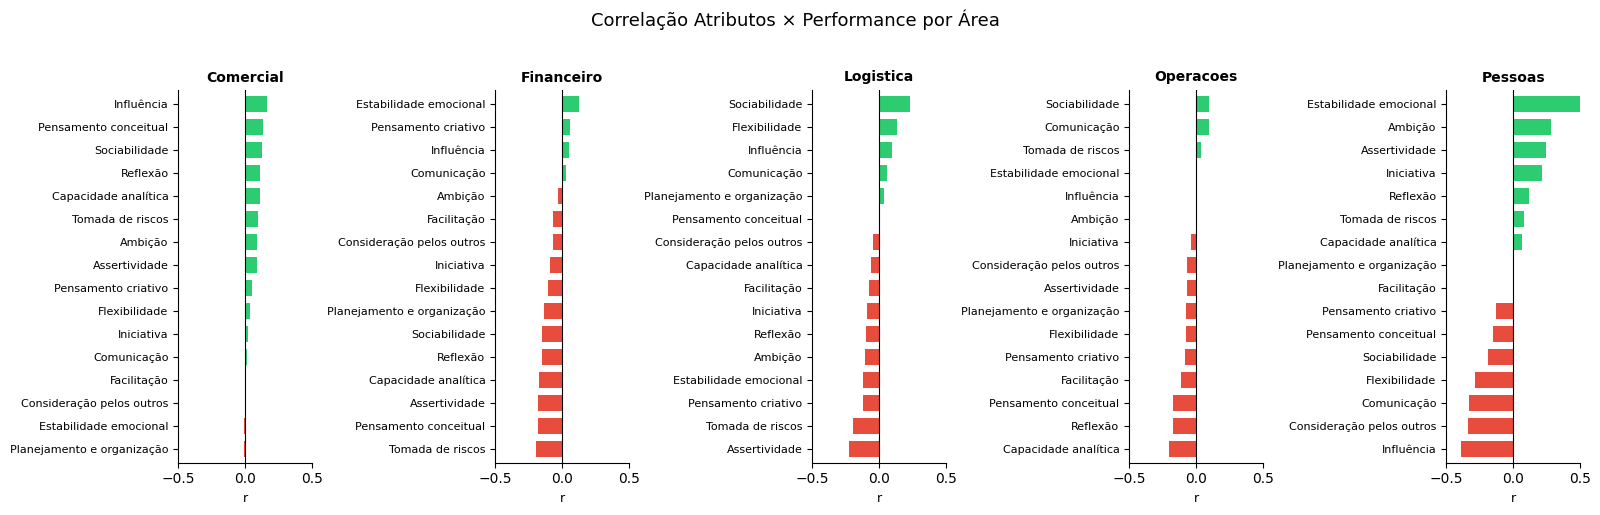

In [12]:
cols_perf = [c for c in df.columns if c.startswith("perf_")]
cols_atr  = [c for c in df.columns if c.startswith("atributo-")]

df_corr = df[cols_atr + ["Área"]].copy()
df_corr["perf_media"] = df[cols_perf].mean(axis=1)
df_corr = df_corr.dropna(subset=["perf_media"] + cols_atr)

corr_por_area = (
    df_corr.groupby("Área")
    .apply(lambda g: g[cols_atr].corrwith(g["perf_media"]))
    .rename(columns=lambda c: c.replace("atributo-", ""))
)

areas = corr_por_area.index.tolist()
fig, axes = plt.subplots(1, len(areas), figsize=(16, 5), sharey=False)

for ax, area in zip(axes, areas):
    top = corr_por_area.loc[area].sort_values()
    cores = ["#e74c3c" if v < 0 else "#2ecc71" for v in top]
    top.plot(kind="barh", ax=ax, color=cores, width=0.7)
    ax.set_title(area, fontweight="bold", fontsize=10)
    ax.set_xlabel("r", fontsize=9)
    ax.set_xlim(-0.5, 0.5)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.tick_params(axis="y", labelsize=8)
    sns.despine(ax=ax)

fig.suptitle("Correlação Atributos × Performance por Área", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

As correlações são fracas a moderadas em geral (|r| < 0.3) — performance é multifatorial e os atributos capturam só uma dimensão. O padrão varia entre áreas: o que gera resultado em Comercial não é necessariamente o que gera em Operações, o que tem implicação direta em recrutamento e desenvolvimento. Financeiro e Pessoas (n < 30) têm correlações menos confiáveis.

**Correlação positiva:** funcionários com score mais alto naquele atributo tendem a ter performance mais alta naquela área. O atributo está alinhado ao que a área exige — candidato a critério de seleção e desenvolvimento.

**Correlação negativa:** o atributo está mal ajustado ao contexto daquela área. Não significa que o atributo é ruim — "Tomada de riscos" pode ser negativo em Operações (que valoriza consistência) e positivo em Comercial (onde arriscar é parte do trabalho). É por isso que a análise por área é mais útil do que a correlação global.

## 11. Tempo de Conclusão vs Score do Assessment

Quem demora mais no teste tira nota maior? Calculamos a duração de cada assessment (Fim − Início) e correlacionamos com o score. Outliers extremos (pessoas que claramente deixaram o teste aberto por horas ou dias) são filtrados pelo percentil 95.

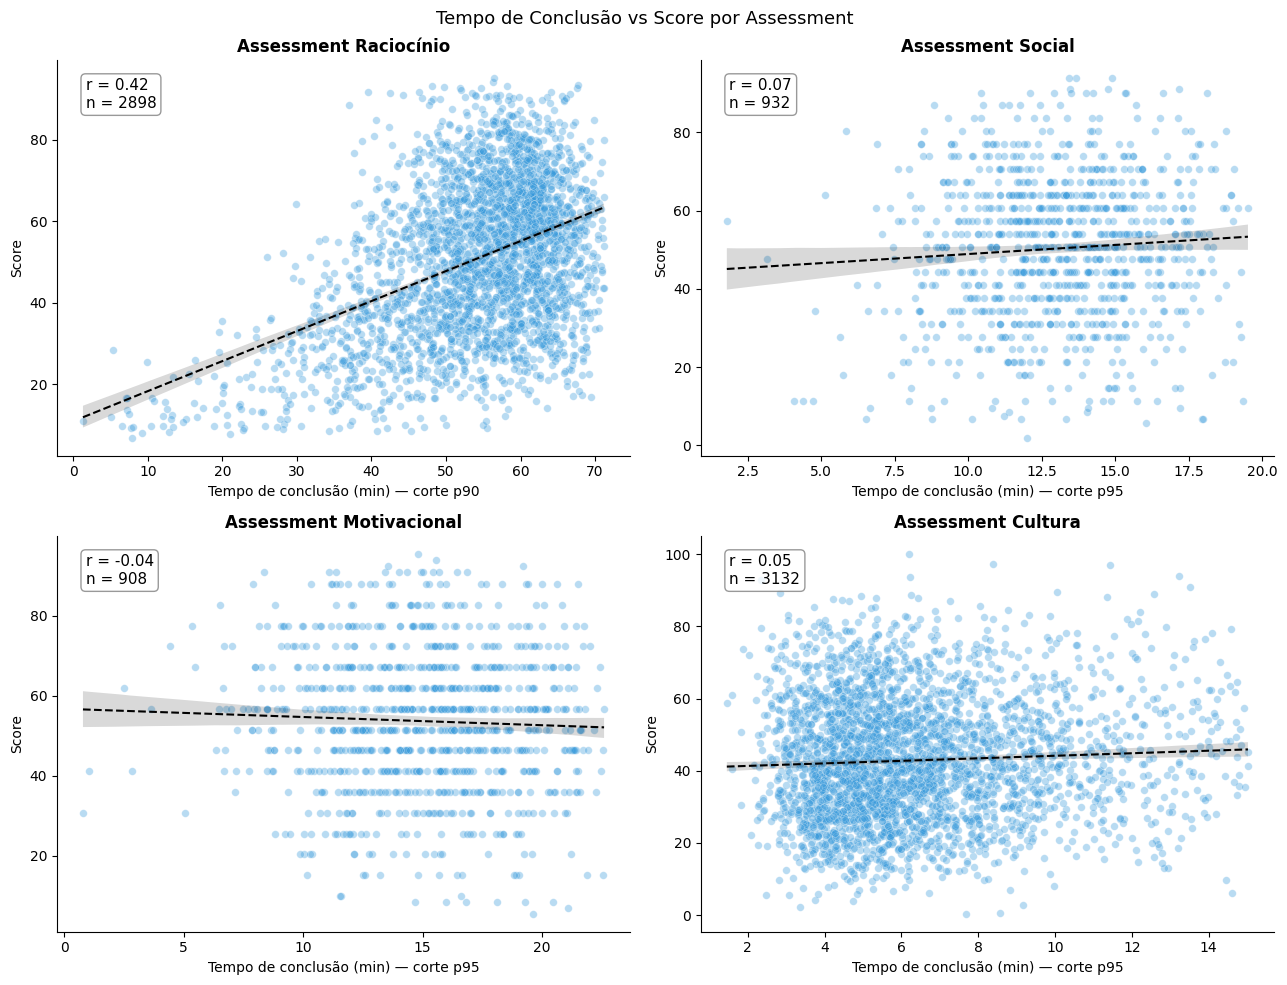

In [14]:
assessments = [
    ("Raciocínio",   "Raciocínio",       "Início - Raciocínio",   "Fim - Raciocínio",   0.90),
    ("Social",       "Social",           "Início - Social",       "Fim - Social",       0.95),
    ("Motivacional", "Motivacional",     "Início - Motivacional", "Fim - Motivacional", 0.95),
    ("Cultura",      "Cultura pontuação","Início - Cultura",      "Fim - Cultura",      0.95),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, (nome, score_col, ini_col, fim_col, pct_corte) in zip(axes, assessments):
    dur = (df[fim_col] - df[ini_col]).dt.total_seconds() / 60
    dados = pd.DataFrame({"dur": dur, "score": df[score_col]}).dropna()
    dados = dados[dados["dur"] > 0]

    corte = dados["dur"].quantile(pct_corte)
    dados = dados[dados["dur"] <= corte]

    r = dados["dur"].corr(dados["score"])

    sns.scatterplot(data=dados, x="dur", y="score", alpha=0.35, s=30, color="#3498db", ax=ax)
    sns.regplot(data=dados, x="dur", y="score", scatter=False, color="black",
                line_kws={"linewidth": 1.5, "linestyle": "--"}, ax=ax)

    ax.annotate(f"r = {r:.2f}\nn = {len(dados)}",
                xy=(0.05, 0.88), xycoords="axes fraction", fontsize=11,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

    ax.set_title(f"Assessment {nome}", fontweight="bold")
    ax.set_xlabel(f"Tempo de conclusão (min) — corte p{int(pct_corte*100)}")
    ax.set_ylabel(f"Score")
    sns.despine(ax=ax)

fig.suptitle("Tempo de Conclusão vs Score por Assessment", fontsize=13)
plt.tight_layout()
plt.show()

Para Social, Motivacional e Cultura a correlação é praticamente nula (|r| < 0.10) — velocidade de resposta não influencia o resultado. Esses assessments capturam traços mais estáveis, independente do esforço pontual.

Raciocínio é o caso interessante: correlação levemente negativa (r ≈ −0.13), o que faz sentido em testes cognitivos — quem resolve mais rápido tende a ter maior capacidade e pontuação maior. A mediana de duração do Raciocínio (~57 min) é bem maior do que os demais (~8–15 min), o que já mostra que é um teste diferente em carga.

## 12. Clusterização de Funcionários por Perfil Comportamental

Usando os 16 atributos comportamentais, aplicamos K-Means para identificar arquétipos naturais na base — grupos de funcionários com perfis similares, sem usar performance ou potencial como critério de agrupamento.

A lógica é: primeiro identificamos os perfis sem olhar performance, depois vemos qual perfil entrega mais em cada contexto. Isso é mais robusto do que correlacionar atributos diretamente com performance.

**O que cada gráfico mostra:**

- **Cotovelo + Silhouette:** quantos grupos criar? O cotovelo mostra onde o ganho de adicionar mais grupos começa a valer menos. O silhouette mede o quão bem separados os grupos ficaram. Juntos justificam a escolha de k=4.

- **Radar 2×2:** como é o perfil comportamental de cada grupo? A área preenchida mostra quais atributos são altos ou baixos — permite nomear o arquétipo (ex: Comunicação, Sociabilidade e Influência altos → "Perfil Relacional").

- **Heatmap área × perfil:** qual arquétipo performa melhor em cada área? Verde = performa bem, vermelho = performa mal. O ★ marca o perfil ideal de cada área.

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

cols_perf = [c for c in df.columns if c.startswith("perf_")]
cols_atr  = [c for c in df.columns if c.startswith("atributo-")]
nomes_atr = [c.replace("atributo-", "") for c in cols_atr]

df_cl = df[cols_atr + ["Área"]].copy()
df_cl["perf_media"] = df[cols_perf].mean(axis=1)
df_cl = df_cl.dropna(subset=cols_atr)

X = df_cl[cols_atr].values
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

# ── gráfico 1: cotovelo + silhouette ──────────────────────────────────────
ks = range(2, 9)
inertias, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(Xs)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(Xs, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(list(ks), inertias, marker="o", color="#3498db")
ax1.axvline(4, color="red", linestyle="--", alpha=0.6, label="k=4 escolhido")
ax1.set_xlabel("Número de clusters (k)")
ax1.set_ylabel("Inércia")
ax1.set_title("Método do Cotovelo")
ax1.legend()
sns.despine(ax=ax1)

ax2.plot(list(ks), silhouettes, marker="o", color="#2ecc71")
ax2.axvline(4, color="red", linestyle="--", alpha=0.6, label="k=4 escolhido")
ax2.set_xlabel("Número de clusters (k)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette por k")
ax2.legend()
sns.despine(ax=ax2)
plt.tight_layout()
plt.show()

# ── aplicar k=4 ───────────────────────────────────────────────────────────
K = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)
df_cl["cluster"] = km.fit_predict(Xs)

cores_cl = ["#3498db", "#2ecc71", "#e74c3c", "#e67e22"]
nomes_cl = [f"Perfil {i+1}" for i in range(K)]
df_cl["perfil"] = df_cl["cluster"].map(dict(enumerate(nomes_cl)))

centros = df_cl.groupby("perfil")[cols_atr].mean()
centros.columns = nomes_atr

# ── gráfico 2: radar dos 4 clusters ──────────────────────────────────────
N = len(nomes_atr)
angulos = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angulos += angulos[:1]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), subplot_kw=dict(polar=True))
axes = axes.flatten()

for idx, (perfil, cor) in enumerate(zip(nomes_cl, cores_cl)):
    ax = axes[idx]
    vals = centros.loc[perfil].tolist() + [centros.loc[perfil].tolist()[0]]
    n = (df_cl["perfil"] == perfil).sum()
    ax.plot(angulos, vals, color=cor, linewidth=2)
    ax.fill(angulos, vals, color=cor, alpha=0.2)
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(nomes_atr, size=7)
    ax.set_ylim(0, 100)
    ax.set_yticks([25, 50, 75])
    ax.set_yticklabels(["25", "50", "75"], size=7, color="grey")
    ax.set_title(f"{perfil}  (n={n})", fontweight="bold", pad=15, color=cor)
    ax.grid(color="grey", linestyle="--", linewidth=0.5, alpha=0.5)

fig.suptitle("Arquétipos Comportamentais — K-Means (k=4)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── gráfico 3: performance por perfil × área (heatmap) ───────────────────
df_validos = df_cl.dropna(subset=["perf_media"])
perf_area_perfil = (
    df_validos.groupby(["Área", "perfil"])["perf_media"]
    .mean()
    .unstack()
    .reindex(columns=nomes_cl)
)

# contar n por célula para anotar
n_area_perfil = (
    df_validos.groupby(["Área", "perfil"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=nomes_cl)
)

# máximo por área → perfil ideal
perfil_ideal = perf_area_perfil.idxmax(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    perf_area_perfil, annot=False,
    cmap="RdYlGn", vmin=1.5, vmax=2.5,
    linewidths=0.5, ax=ax
)

# anotar: performance + n + estrela no melhor
for i, area in enumerate(perf_area_perfil.index):
    for j, perfil in enumerate(nomes_cl):
        val = perf_area_perfil.loc[area, perfil]
        n   = n_area_perfil.loc[area, perfil]
        if pd.isna(val):
            continue
        estrela = " ★" if perfil == perfil_ideal[area] else ""
        ax.text(j + 0.5, i + 0.4, f"{val:.2f}{estrela}",
                ha="center", va="center", fontsize=10, fontweight="bold", color="black")
        ax.text(j + 0.5, i + 0.68, f"n={n}",
                ha="center", va="center", fontsize=8, color="#444")

ax.set_title("Performance Média por Perfil Comportamental e Área\n★ = perfil ideal da área", fontsize=12)
ax.set_xlabel("Perfil Comportamental")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print("Perfil ideal por área:")
for area, perfil in perfil_ideal.items():
    top3 = centros.loc[perfil].nlargest(3).index.tolist()
    print(f"  {area}: {perfil} — atributos dominantes: {' | '.join(top3)}")

ModuleNotFoundError: No module named 'sklearn'

O cotovelo e o silhouette apontam k=4 como o melhor equilíbrio — após esse ponto os ganhos são marginais. Silhouettes baixos (~0.15) são normais com dados comportamentais: pessoas existem num espectro contínuo, não em grupos discretos. Os clusters representam tendências centrais, não categorias rígidas.

Cada arquétipo tem atributos dominantes distintos visíveis nos radares. O gráfico de performance por arquétipo responde a questão estratégica: algum perfil entrega sistematicamente mais? Se sim, esse perfil vira critério de seleção. Se não, reforça que o contexto e a gestão importam mais do que o perfil em si.

## 13. Fit Cultural — Distribuição de Classificações e Impacto na Performance

As seções anteriores mostraram o fit cultural por área. Aqui analisamos a distribuição geral das classificações (Baixo → Muito-Alto) e se funcionários com maior fit cultural entregam mais performance.

Se a cultura for preditora de performance, o fit cultural deve entrar como critério de seleção — além de ser um indicador de engajamento.

In [ ]:
cols_perf = [c for c in df.columns if c.startswith("perf_")]
class_col = "Cultura classificação"

ordem_cult = ["Muito-Baixo", "Baixo", "Medio-Baixo", "Medio",
              "Medio-Alto", "Alto", "Muito-Alto"]

if class_col in df.columns:
    df_cult = df[[class_col]].copy()
    df_cult["perf_media"] = df[cols_perf].mean(axis=1)
    df_cult = df_cult.dropna(subset=[class_col])
    classes_pres = [c for c in ordem_cult if c in df_cult[class_col].unique()]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # Distribuição de classificações
    dist = df_cult[class_col].value_counts().reindex(classes_pres)
    cores_bar = ["#c0392b", "#e67e22", "#f1c40f", "#27ae60",
                 "#2ecc71", "#1abc9c", "#16a085"]
    ax1.bar(dist.index, dist.values,
            color=cores_bar[:len(classes_pres)], edgecolor="white")
    ax1.set_title("Distribuição de Fit Cultural")
    ax1.set_xlabel("Classificação")
    ax1.set_ylabel("Número de Funcionários")
    ax1.tick_params(axis="x", rotation=30)
    for i, v in enumerate(dist.values):
        ax1.text(i, v + 5, str(v), ha="center", fontsize=9)
    sns.despine(ax=ax1)

    # Boxplot de performance por classificação de fit cultural
    df_cp = df_cult.dropna(subset=["perf_media"])
    if len(df_cp) > 5:
        sns.boxplot(data=df_cp, x=class_col, y="perf_media",
                    order=classes_pres, palette="RdYlGn", ax=ax2)
        ax2.set_title("Performance Média por Fit Cultural")
        ax2.set_xlabel("Classificação de Fit Cultural")
        ax2.set_ylabel("Média de Performance (1–3)")
        ax2.set_ylim(0.8, 3.2)
        ax2.tick_params(axis="x", rotation=30)
        sns.despine(ax=ax2)

    plt.tight_layout()
    plt.show()

    # Tabela resumo
    tbl = (df_cp.groupby(class_col)["perf_media"]
           .agg(["mean", "std", "count"])
           .rename(columns={"mean": "Perf Média", "std": "DP", "count": "n"})
           .round(2)
           .reindex(classes_pres))
    print("\nPerformance por nível de fit cultural:")
    print(tbl.to_string())
else:
    print("Coluna 'Cultura classificação' não encontrada.")


Se os boxplots de performance forem similares entre classificações de cultura (como acontece com o Potencial Bruto), o fit cultural tem efeito limitado no curto prazo — mas isso não invalida o instrumento. Cultura tende a impactar retenção e engajamento em horizontes mais longos, e esses efeitos não aparecem numa janela de dois anos. O n por classificação varia bastante, especialmente nas faixas extremas, então as caudas merecem cautela.

## 14. Trajetórias de Performance Individual

Calculamos a tendência individual de cada funcionário com ≥ 2 avaliações e classificamos em três trajetórias:

- **Crescente** — último score maior que o primeiro
- **Estável** — primeiro e último iguais
- **Decrescente** — último score menor que o primeiro

A seguir, a trajetória média de cada grupo e alguns exemplos individuais.

In [ ]:
import numpy as np

cols_perf = [c for c in df.columns if c.startswith("perf_")]

def extrair_tempo(c):
    parts = c.split("_")
    return int(parts[2]), int(parts[1])

ordem_e = sorted(cols_perf, key=extrair_tempo)
labels_e = {c: f"{c.split('_')[2]}-{c.split('_')[1]}º" for c in ordem_e}

# Filtrar funcionários com ≥ 2 avaliações
n_aval = df[cols_perf].notna().sum(axis=1)
df_traj = df[n_aval >= 2].copy()

# Classificar trajetória (primeiro vs último score não-nulo)
def trajetoria(row):
    vals = [row[c] for c in ordem_e if pd.notna(row[c])]
    if len(vals) < 2:
        return None
    diff = vals[-1] - vals[0]
    if diff > 0:
        return "Crescente"
    elif diff == 0:
        return "Estável"
    else:
        return "Decrescente"

df_traj["trajetoria"] = df_traj.apply(trajetoria, axis=1)
contagem_traj = df_traj["trajetoria"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribuição das trajetórias
cores_traj = {"Crescente": "#2ecc71", "Estável": "#3498db", "Decrescente": "#e74c3c"}
cores_ord = [cores_traj[t] for t in contagem_traj.index]
axes[0].bar(contagem_traj.index, contagem_traj.values, color=cores_ord, edgecolor="white")
for i, v in enumerate(contagem_traj.values):
    axes[0].text(i, v + 1, str(v), ha="center", fontsize=10)
axes[0].set_title("Trajetórias de Performance Individual")
axes[0].set_xlabel("Tipo de Trajetória")
axes[0].set_ylabel("Número de Funcionários")
sns.despine(ax=axes[0])

# Trajetória média por grupo
ax2 = axes[1]
for tipo, cor in cores_traj.items():
    grupo = df_traj[df_traj["trajetoria"] == tipo]
    if len(grupo) == 0:
        continue
    medias = [grupo[c].mean() for c in ordem_e]
    ns = [grupo[c].notna().sum() for c in ordem_e]
    labels_plot = [labels_e[c] for c in ordem_e]
    # Usar apenas semestres com ≥ 10 registros no grupo
    xs = [labels_plot[i] for i, n in enumerate(ns) if n >= 5]
    ys = [medias[i] for i, n in enumerate(ns) if n >= 5]
    if xs:
        ax2.plot(xs, ys, marker="o", label=f"{tipo} (n={len(grupo)})",
                 color=cor, linewidth=2)

ax2.set_title("Trajetória Média por Grupo")
ax2.set_xlabel("Semestre")
ax2.set_ylabel("Score Médio de Performance")
ax2.set_ylim(1.0, 3.0)
ax2.legend()
ax2.tick_params(axis="x", rotation=30)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

print("\nDistribuição de trajetórias:")
print(contagem_traj.to_string())
pct = contagem_traj / contagem_traj.sum() * 100
print("\n% do total com ≥ 2 avaliações:")
print(pct.round(1).to_string())


A maioria mantém trajetória estável, o que é consistente com a concentração no score 2. O grupo crescente — se expressivo — indica que o ambiente ou o desenvolvimento tem efeito real em parte da população. O grupo decrescente é o de maior atenção: funcionários que regrediram podem estar em cargos inadequados, com gestão difícil ou sofrendo burnout. A análise individual (disponível no dashboard) permite identificar os casos específicos.

## 15. Regressão Múltipla — O que mais explica a performance?

Até aqui analisamos cada dimensão isolada. A regressão linear múltipla controla todas as variáveis ao mesmo tempo e responde: qual preditor tem maior peso quando os outros estão presentes?

Usamos como variáveis independentes os 4 scores de assessment (Raciocínio, Social, Motivacional, Cultura) e os 16 atributos comportamentais, padronizados para que os coeficientes sejam comparáveis. Variável dependente: performance média do funcionário. O R² indica quanto da variância de performance o conjunto explica.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import numpy as np

cols_perf = [c for c in df.columns if c.startswith("perf_")]
cols_atr  = [c for c in df.columns if c.startswith("atributo-")]

assessments_r = [c for c in ["Raciocínio", "Social", "Motivacional", "Cultura pontuação"]
                 if c in df.columns]
features_reg = assessments_r + cols_atr
nomes_feat = [f.replace("atributo-", "") for f in features_reg]

df_reg = df[features_reg].copy()
df_reg["perf_media"] = df[cols_perf].mean(axis=1)
df_reg = df_reg.dropna()

if len(df_reg) > 20:
    X = StandardScaler().fit_transform(df_reg[features_reg].values)
    y = df_reg["perf_media"].values
    reg = LinearRegression().fit(X, y)
    r2  = reg.score(X, y)

    coefs = sorted(zip(nomes_feat, reg.coef_), key=lambda x: abs(x[1]), reverse=True)
    nomes_ord, coefs_ord = zip(*coefs)

    cores_coef = ["#2ecc71" if c > 0 else "#e74c3c" for c in coefs_ord]

    fig, ax = plt.subplots(figsize=(10, max(5, len(nomes_ord) * 0.35)))
    ax.barh(list(reversed(nomes_ord)), list(reversed(coefs_ord)),
            color=list(reversed(cores_coef)), edgecolor="white")
    ax.axvline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"Coeficientes Padronizados da Regressão  (R² = {r2:.3f})", fontsize=12)
    ax.set_xlabel("Coeficiente padronizado (verde = positivo, vermelho = negativo)")
    ax.set_ylabel("Variável")
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()

    print(f"R² = {r2:.4f}  →  {r2*100:.1f}% da variância de performance explicada")
    print(f"n  = {len(df_reg):,} funcionários com todos os dados disponíveis\n")
    print("Top 5 preditores (valor absoluto do coeficiente):")
    for nome, coef in coefs[:5]:
        sinal = "↑" if coef > 0 else "↓"
        print(f"  {sinal} {nome}: {coef:.4f}")
else:
    print(f"Dados insuficientes para regressão (n={len(df_reg)}).")


R² baixo (~0.05–0.20) é esperado em análises comportamentais — performance é multifatorial e boa parte da variância está em coisas que os dados não capturam (qualidade da gestão, clareza de papel, contexto de mercado). Os coeficientes padronizados revelam o peso relativo de cada variável quando todas competem simultaneamente, o que é diferente das correlações bivariadas vistas antes. Variáveis com coeficiente negativo não são necessariamente ruins — podem refletir multicolinearidade entre atributos correlacionados. Os preditores mais fortes devem orientar critérios de seleção e desenvolvimento, mas validados por área — o modelo global pode ocultar padrões locais.

---

## Conclusões Gerais

4.281 funcionários, 4 semestres (2017–2019), cobertura variada: 3.311 com avaliação de Cultura, 928 com Potencial Bruto, 921 com perfil comportamental completo.

---

### Performance

A distribuição de scores é estável e concentrada no nível 2 em todos os semestres de maior cobertura (2018 em diante) — 60–70% dos avaliados. A cobertura cresceu de 8% em 2017-2º para ~34% em 2019-1º. As médias por área ficam todas entre 1.9 e 2.1, sem destaque positivo ou negativo consistente.

### O Potencial Bruto não prediz performance

O achado mais relevante: **r ≈ −0.07** entre Potencial Bruto e performance. Isso se sustenta em múltiplas perspectivas — nenhuma das três dimensões do Potencial (Raciocínio, Social, Motivacional) apresenta correlação significativa, a Matriz 9-Box confirma visualmente e a regressão múltipla confirma com controle estatístico. O instrumento pode não estar capturando o que de fato converte em entrega — ou o horizonte de dois anos é curto demais para a relação aparecer.

### Fit Cultural

Mediana de Cultura em ~42/100, com a maioria nas faixas Baixo e Médio-Baixo. O impacto na performance de curto prazo parece limitado, mas cultura tende a influenciar retenção e engajamento em horizontes mais longos. O padrão é consistente entre áreas, sugerindo desalinhamento sistêmico nos critérios de contratação.

### Atributos comportamentais

Os 16 atributos têm poder preditivo fraco a moderado individualmente (|r| < 0.3). O padrão varia por área — o que gera resultado em Comercial não é o mesmo que em Operações. A regressão múltipla identifica quais atributos têm maior peso quando tudo compete ao mesmo tempo. A clusterização K-Means identificou 4 arquétipos comportamentais com perfis e performance distintos por área.

### Trajetórias individuais

A maioria mantém trajetória estável, consistente com a concentração no score 2. O grupo decrescente é o de atenção — podem estar em cargos inadequados ou passando por dificuldades não endereçadas. O grupo crescente valida que ambiente e desenvolvimento têm efeito real em parte da população.

### Qualidade dos assessments

Tempo de conclusão não correlaciona com score em Social, Motivacional e Cultura (|r| < 0.10). Raciocínio tem correlação levemente negativa (r ≈ −0.13), esperado em testes cognitivos. **Nota:** a coluna `Match` é 100% nula na base — análises que dependiam dessa dimensão não foram possíveis.

---

### Próximos passos

1. **Análise por nível hierárquico** — a relação potencial × performance pode ser mais clara em cargos de liderança
2. **Horizonte temporal maior** — acompanhar a evolução individual ao longo de mais semestres para capturar efeitos de desenvolvimento
3. **Regressão por área** — o modelo global pode ocultar padrões locais
4. **Validação do instrumento de Potencial** — investigar se a correlação melhora em subgrupos específicos (área, tempo de casa, cargo)

---

## O que impede a empresa de ter mais performance?

Os dados apontam para quatro hipóteses estruturais que, combinadas, podem estar limitando o teto de performance da organização:

---

### Hipótese 1 — Estão selecionando pelo critério errado

O Potencial Bruto — principal instrumento de avaliação da empresa — tem correlação de **r ≈ −0.07** com a performance entregue. Se esse score é usado para contratar, promover ou priorizar desenvolvimento, as decisões estão sendo tomadas com uma régua que não mede o que importa.

Os dados sugerem que o **perfil comportamental por área** (seção 10) tem mais sinal do que o Potencial Bruto global. O perfil ideal para Comercial é diferente do ideal para Operações — uma política de seleção uniforme ignora essa variação e aumenta a chance de desajuste.

---

### Hipótese 2 — Fit cultural baixo como teto silencioso

A mediana de Cultura é **42/100** em toda a empresa, com a maioria dos funcionários nas faixas Baixo e Médio-Baixo. Funcionários que não se identificam com a cultura tendem a se engajar menos, colaborar menos e entregar menos — independente de capacidade técnica ou potencial avaliado.

Esse é um teto silencioso: nenhuma intervenção de treinamento ou feedback resolve desalinhamento de valores. A solução começa na seleção.

---

### Hipótese 3 — O quadrante Enigma representa desperdício ativo

**19 funcionários** com alto potencial avaliado e baixa performance (quadrante Enigma da 9-Box). Se o potencial é real, algo no ambiente está impedindo a entrega — cargo errado, gestão inadequada, falta de clareza de expectativas ou ausência de suporte.

Esse grupo tem o **maior ROI potencial de intervenção**: são pessoas que a empresa já investiu em avaliar e que teoricamente têm capacidade — falta descobrir o que as trava. Uma conversa estruturada com cada um deles pode revelar padrões acionáveis.

---

### Hipótese 4 — A avaliação de performance pode estar viciada

Em todos os semestres e áreas, **60–70% dos funcionários recebem sempre o score 2 (Atende expectativas)**. Essa estabilidade excessiva é improvável em qualquer distribuição real de performance — o mais provável é que gestores evitem dar scores extremos por pressão social, medo de conflito ou ausência de critérios claros.

Quando a avaliação perde poder discriminatório, ela deixa de cumprir sua função: **não diferencia quem se destaca de quem está estagnado**, elimina o sinal necessário para decisões de promoção e desenvolvimento, e desmotiva quem realmente entrega acima da média ao equipará-los com a maioria.

---

## Recomendações para Melhorar a Performance

Para cada barreira identificada, há uma alavanca acionável. As recomendações abaixo são ordenadas por **impacto estimado × facilidade de implementação**.

---

### 1. Redesenhar o critério de seleção por área

**O problema:** o Potencial Bruto não prediz performance, mas os atributos comportamentais por área têm sinal.

**A ação:** usar o perfil comportamental ideal por área (seção 12 — heatmap ★) como critério primário de seleção, substituindo ou complementando o Potencial Bruto global. Cada área passa a ter seu "perfil de sucesso" baseado em quem já entrega bem — não em uma teoria geral de potencial.

**Impacto esperado:** redução de desajuste de perfil → menos tempo até produtividade plena → menos turnover involuntário.

---

### 2. Incorporar fit cultural como filtro de entrada

**O problema:** mediana de cultura em 42/100 — a maioria dos funcionários tem baixo alinhamento com os valores da empresa.

**A ação:** usar a pontuação de Cultura como critério eliminatório (ou de peso) no processo seletivo, priorizando candidatos acima do percentil 50. Internamente, mapear as áreas com menor fit cultural médio e investigar se há padrão de liderança ou contexto que explique o desalinhamento.

**Impacto esperado:** equipes mais coesas, maior engajamento orgânico e menor fricção cultural — fatores que pesquisas de People Analytics associam diretamente a ganhos de performance.

---

### 3. Plano de ação imediato para o quadrante Enigma

**O problema:** 19 pessoas com alto potencial avaliado e baixa performance — o grupo de maior desperdício identificado.

**A ação:**
1. Listar os 19 funcionários (seção 7 — `listar_quadrante("Enigma")`)
2. Entrevista estruturada com cada um: o que está faltando para entregar mais? (clareza de papel, suporte, ferramentas, relação com gestor?)
3. Cruzar com o perfil de atributos deles — se os atributos dominantes forem incompatíveis com as demandas do cargo atual, considerar realocação
4. Definir prazo de 90 dias com metas claras e reavaliação

**Impacto esperado:** converter até 50% desse grupo para performance média ou alta representaria um ganho direto e mensurável sem nenhuma contratação nova.

---

### 4. Calibrar o processo de avaliação de performance

**O problema:** 60–70% sempre no score 2 — avaliação sem poder discriminatório.

**A ação:**
- Treinar gestores em calibração de performance com exemplos concretos do que distingue score 1, 2 e 3 no contexto de cada área
- Implementar sessões de calibração em comitê (ao menos para as faixas extremas) para reduzir viés individual
- Considerar distribuição forçada suave (ex: no máximo 70% no score 2) para forçar diferenciação — com cuidado para não criar distorções

**Impacto esperado:** avaliações mais precisas geram decisões melhores de promoção, desenvolvimento e desligamento — e enviam um sinal claro para quem performa acima da média de que isso é reconhecido.

---

### 5. Desenvolvimento por arquétipo comportamental

**O problema:** programas de desenvolvimento genéricos ignoram que cada perfil tem gaps distintos.

**A ação:** usar os 4 arquétipos do K-Means (seção 12) para segmentar os planos de desenvolvimento individual. Cada perfil tem atributos dominantes e lacunas — um "Perfil Relacional" precisa de um PDI diferente de um "Perfil Analítico". Isso torna o desenvolvimento mais preciso e com maior chance de conversão em performance real.

**Impacto esperado:** ROI maior dos investimentos em T&D, com desenvolvimento direcionado aos gaps que de fato diferenciam performance em cada área.